In [1]:
# Import necessary libraries
import wandb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import json

# Login to wandb (if not already logged in)
wandb.login()

# Define the project and entity
project_name = "Negatives_calibration"
entity_name = "ntourne"

# Initialize the wandb API
api = wandb.Api()

# Fetch all runs from the project
runs = api.runs(f"{entity_name}/{project_name}")

/data/home/natant/anaconda3/envs/Negs2/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/data/home/natant/anaconda3/envs/Negs2/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happ

# Loading Data and Quality control

In [2]:
# Initialize a list to store results
results = []

# Iterate through runs and extract metrics
for run in runs:
    # Get the summary metrics, config, and name of the run
    summary = run.summary._json_dict
    if isinstance(summary, str):
        summary = json.loads(summary)
    config = run.config
    if isinstance(config, str):
        config = json.loads(config)
    name = run.name
    
    # Combine the data into a single dictionary
    run_data = {
        "run_name": name,
        "TF": config.get("TF")["value"],
        "celltype": config.get("celltype")["value"],
        "neg_mode": [config.get("neg_mode")["value"] if "neg_mode" in config else "HQ training"][0],
        "cross_val_set": config.get("cross_val_set")["value"],
        "group_name": config.get("group_name")["value"],
        "AUROC": summary.get("test_AUROC"),
        "AUROC_HQ": summary.get("test_AUROC_HQ"),
        "val_loss": summary.get("val_loss"),
        "Accuracy": summary.get("test_Accuracy"),
        "Accuracy_HQ": summary.get("test_Accuracy_HQ"),
        "Average_Precision": summary.get("test_Average_precision"),
        "Average_Precision_HQ": summary.get("test_Average_precision_HQ"),
        "Matthews_Correlation": summary.get("test_Matthews_corr_coef"),
        "Matthews_Correlation_HQ": summary.get("test_Matthews_corr_coef_HQ"),
        "Precision": summary.get("test_Precision"),
        "Precision_HQ": summary.get("test_Precision_HQ"),
        "Specificity": summary.get("test_Specificity"),
        "Specificity_HQ": summary.get("test_Specificity_HQ")
    }
    results.append(run_data)

# Convert the results into a DataFrame
results_df = pd.DataFrame(results)
results_df = results_df[results_df["celltype"] == "GM12878"]

In [3]:
pd.DataFrame(results)

,run_name,TF,celltype,neg_mode,cross_val_set,group_name,AUROC,AUROC_HQ,val_loss,Accuracy,Accuracy_HQ,Average_Precision,Average_Precision_HQ,Matthews_Correlation,Matthews_Correlation_HQ,Precision,Precision_HQ,Specificity,Specificity_HQ
0,GM12878_CTCF_dinucl_sampled_CV1_20251121_15:18,CTCF,GM12878,dinucl_sampled,1,learning_rate,0.980528,0.962120,0.178230,0.936718,0.821124,0.988297,0.811397,0.860771,0.530508,0.945441,0.375867,0.898507,0.804339
1,GM12878_CTCF_dinucl_sampled_CV0_20251121_15:18,CTCF,GM12878,dinucl_sampled,0,learning_rate,0.980565,0.963824,0.205777,0.937037,0.835783,0.988657,0.813131,0.862034,0.541338,0.946270,0.382465,0.901399,0.821840
2,GM12878_CTCF_dinucl_sampled_CV1_20251121_15:18,CTCF,GM12878,dinucl_sampled,1,learning_rate,0.979473,0.961317,0.174246,0.936879,0.837615,0.987461,0.808424,0.861665,0.551191,0.950771,0.398984,0.909479,0.823564
3,GM12878_CTCF_dinucl_sampled_CV0_20251121_15:18,CTCF,GM12878,dinucl_sampled,0,learning_rate,0.980534,0.963541,0.174601,0.935611,0.831119,0.988631,0.811014,0.858872,0.534322,0.944760,0.375630,0.898532,0.816711
4,GM12878_CTCF_dinucl_sampled_CV0_20251121_15:18,CTCF,GM12878,dinucl_sampled,0,learning_rate,0.980632,0.964050,0.174480,0.937363,0.851368,0.988746,0.813403,0.863428,0.561869,0.952743,0.406454,0.914469,0.839994
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
716,GM12878_SP1_dinucl_sampled_CV1_20251127_14:50,SP1,GM12878,dinucl_sampled,1,learning_rate_take_2,NaN,NaN,0.486326,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
717,GM12878_SP1_dinucl_sampled_CV2_20251127_14:57,SP1,GM12878,dinucl_sampled,2,learning_rate_take_2,0.862834,0.763059,0.533788,0.787526,0.489922,0.904460,0.173320,0.544358,0.140223,0.811549,0.075915,0.680297,0.471408
718,GM12878_SP1_dinucl_sampled_CV2_20251127_15:05,SP1,GM12878,dinucl_sampled,2,learning_rate_take_2,NaN,NaN,0.498521,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
719,GM12878_SP1_dinucl_sampled_CV3_20251127_15:09,SP1,GM12878,dinucl_sampled,3,learning_rate_take_2,NaN,NaN,0.451769,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
results_df = pd.DataFrame(results)
results_df = results_df[results_df["celltype"] == "GM12878"]
results_df = results_df[results_df['group_name'].isin(["learning_rate_take_2"])] # select the right groups
# HQ_results = pd.DataFrame(results)
# HQ_results = HQ_results[HQ_results['group_name'] == "full_run_3_HQ"]
# HQ_results["neg_mode"] = "HQ training"
# HQ_results = HQ_results.rename(columns={"AUROC": "AUROC_HQ", "AUROC_HQ": "AUROC"})
# HQ_results = HQ_results[HQ_results['celltype'].isin(['A549', 'GM12878', 'K562', 'HepG2'])] # only the right celltypes
# Merge results_df with HQ_results, aligning columns as needed
# results_df = pd.concat([results_df, HQ_results], ignore_index=True)

In [5]:
# Exclude rows where neg_mode is 'HQ training' before checking for NaNs in AUROC
mask = results_df["neg_mode"] != "HQ training"
num_nans = results_df.loc[mask, "AUROC"].isna().sum()
print(f"Number of NaNs in AUROC (excluding HQ training): {num_nans}")
results_df.loc[mask & results_df["AUROC"].isna()]

Number of NaNs in AUROC (excluding HQ training): 23


,run_name,TF,celltype,neg_mode,cross_val_set,group_name,AUROC,AUROC_HQ,val_loss,Accuracy,Accuracy_HQ,Average_Precision,Average_Precision_HQ,Matthews_Correlation,Matthews_Correlation_HQ,Precision,Precision_HQ,Specificity,Specificity_HQ
127,GM12878_CTCF_dinucl_sampled_CV1_20251124_12:46,CTCF,GM12878,dinucl_sampled,1,learning_rate_take_2,NaN,NaN,0.201295,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
128,GM12878_CTCF_dinucl_sampled_CV2_20251124_12:46,CTCF,GM12878,dinucl_sampled,2,learning_rate_take_2,NaN,NaN,0.184529,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
129,GM12878_CTCF_dinucl_sampled_CV2_20251124_12:46,CTCF,GM12878,dinucl_sampled,2,learning_rate_take_2,NaN,NaN,0.176561,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
130,GM12878_CTCF_dinucl_sampled_CV0_20251124_12:46,CTCF,GM12878,dinucl_sampled,0,learning_rate_take_2,NaN,NaN,0.200652,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
131,GM12878_CTCF_dinucl_sampled_CV1_20251124_12:46,CTCF,GM12878,dinucl_sampled,1,learning_rate_take_2,NaN,NaN,0.179857,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
132,GM12878_CTCF_dinucl_sampled_CV0_20251124_12:46,CTCF,GM12878,dinucl_sampled,0,learning_rate_take_2,NaN,NaN,0.192033,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
532,GM12878_MAZ_(ab85725)_neighbors_CV1_20251126_1...,MAZ_(ab85725),GM12878,neighbors,1,learning_rate_take_2,NaN,NaN,0.650027,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
536,GM12878_MAZ_(ab85725)_neighbors_CV3_20251126_1...,MAZ_(ab85725),GM12878,neighbors,3,learning_rate_take_2,NaN,NaN,0.647111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
538,GM12878_MAZ_(ab85725)_neighbors_CV4_20251126_1...,MAZ_(ab85725),GM12878,neighbors,4,learning_rate_take_2,NaN,NaN,0.639015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
540,GM12878_MAZ_(ab85725)_neighbors_CV5_20251126_1...,MAZ_(ab85725),GM12878,neighbors,5,learning_rate_take_2,NaN,NaN,0.639693,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


There should be no NaNs!!

In [6]:
# Filter out entries where AUROC_HQ == 0 -> probably an issue with the cross val split 
filtered_out_count = results_df[(results_df['AUROC_HQ'] == 0) | (results_df['AUROC_HQ'].isna())].shape[0]

# Filter the DataFrame to exclude these entries
#results_df = results_df[~((results_df['AUROC_HQ'] == 0) | (results_df['AUROC_HQ'].isna()))]

# Print the count of filtered-out entries
print(f"Number of entries where AUROC_HQ == 0 or NaN: {filtered_out_count}")

Number of entries where AUROC_HQ == 0 or NaN: 23


Also no 0's!!

In [7]:
results_df["celltype_TF"] = results_df["celltype"]+"_"+results_df["TF"]
output = results_df["celltype_TF"].value_counts()
output.to_dict()

{'GM12878_CTCF': 66,
 'GM12878_YY1_(SC-281)': 60,
 'GM12878_TBP': 60,
 'GM12878_Egr-1': 60,
 'GM12878_Mxi1_(AF4185)': 60,
 'GM12878_SRF': 60,
 'GM12878_SIX5': 60,
 'GM12878_USF-1': 60,
 'GM12878_MAZ_(ab85725)': 50,
 'GM12878_ELK1_(1277-1)': 50,
 'GM12878_SP1': 8}

There really shouldn't be any with less runs, so check if something is wrong!!

In [8]:
# Filter out TFs with less than 36 samples
#results_df = results_df.groupby('celltype_TF').filter(lambda x: len(x) >= 36) #! ONLY TAKE THE 4 BIG CELL TYPES

In [9]:
results_df["celltype"].value_counts() 

celltype
GM12878    594
Name: count, dtype: int64

In [10]:
results_df["TF-neg_mode"] = results_df["TF"]+"_"+results_df["neg_mode"]
results_df["TF-neg_mode-celltype"] = results_df["TF"]+"_"+results_df["neg_mode"]+"_"+results_df["celltype"]

In [11]:
tf_per_celltype = results_df.groupby("celltype")["TF"].nunique()
print(tf_per_celltype)

celltype
GM12878    11
Name: TF, dtype: int64


In [12]:
results_df["neg_mode"].value_counts()

neg_mode
dinucl_sampled     124
dinucl_shuffled    120
shuffled           120
neighbors          120
celltype           110
Name: count, dtype: int64

In [13]:
results_df["TF-neg_mode-celltype"].value_counts()[results_df["TF-neg_mode-celltype"].value_counts() <6]

TF-neg_mode-celltype
MAZ_(ab85725)_celltype_GM12878          2
ELK1_(1277-1)_dinucl_sampled_GM12878    2
Name: count, dtype: int64

In [14]:
np.sum([6- i for i in results_df["TF-neg_mode-celltype"].value_counts()[results_df["TF-neg_mode-celltype"].value_counts() <6].values])

np.int64(8)

In [15]:
# Get all possible combinations that should exist
all_combinations = []
for tf in results_df['TF'].unique():
    for celltype in results_df['celltype'].unique():
        for neg_mode in results_df['neg_mode'].unique():
            # Skip combinations that don't exist at all (not all TFs exist in all celltypes)
            if results_df[(results_df['TF'] == tf) & 
                          (results_df['celltype'] == celltype) & 
                          (results_df['neg_mode'] == neg_mode)].shape[0] > 0:
                for cv_fold in range(6):  # 6 folds: 0-5
                    all_combinations.append({
                        'TF': tf,
                        'celltype': celltype,
                        'neg_mode': neg_mode,
                        'cross_val_set': cv_fold
                    })

# Convert to DataFrame
expected_df = pd.DataFrame(all_combinations)

# Merge with actual runs to find missing ones
actual_runs = results_df[['TF', 'celltype', 'neg_mode', 'cross_val_set']].drop_duplicates()
missing_runs = pd.merge(
    expected_df, 
    actual_runs, 
    on=['TF', 'celltype', 'neg_mode', 'cross_val_set'], 
    how='left', 
    indicator=True
)

# Filter to only missing runs
missing_runs = missing_runs[missing_runs['_merge'] == 'left_only'].drop(columns=['_merge'])

# Add group_name based on neg_mode
missing_runs['group_name'] = missing_runs['neg_mode'].apply(
    lambda x: 'full_run_3_HQ' if x == 'HQ training' else 'full_run_3'
)

# Sort for better readability
missing_runs = missing_runs.sort_values(['celltype', 'TF', 'neg_mode', 'cross_val_set']).reset_index(drop=True)

In [16]:
missing_runs

,TF,celltype,neg_mode,cross_val_set,group_name
0,ELK1_(1277-1),GM12878,dinucl_sampled,0,full_run_3
1,ELK1_(1277-1),GM12878,dinucl_sampled,1,full_run_3
2,ELK1_(1277-1),GM12878,dinucl_sampled,2,full_run_3
3,ELK1_(1277-1),GM12878,dinucl_sampled,3,full_run_3
4,ELK1_(1277-1),GM12878,dinucl_sampled,4,full_run_3
5,MAZ_(ab85725),GM12878,celltype,1,full_run_3
6,MAZ_(ab85725),GM12878,celltype,2,full_run_3
7,MAZ_(ab85725),GM12878,celltype,3,full_run_3
8,MAZ_(ab85725),GM12878,celltype,4,full_run_3
9,MAZ_(ab85725),GM12878,celltype,5,full_run_3


In [17]:
# # Write the missing_runs DataFrame to a CSV file
# missing_runs.to_csv("/data/home/natant/Negatives/Runs/full_run_3_missing/missing_runs.csv", index=False)
# print(f"Exported {len(missing_runs)} missing runs to missing_runs.csv")

In [18]:
results_df["AUROC_delta"] = results_df["AUROC"] - results_df["AUROC_HQ"]

In [19]:
import pickle

with open("/data/home/natant/Negatives/testing_ground/20250613_NUMBER_OF_POSITIVES_PER_GROUP.pkl", "rb") as f:
    number_of_positives = pickle.load(f)
# Convert the nested dictionary 'number_of_positives' into a pandas DataFrame
number_of_positives_df = (
    pd.DataFrame([
        {"celltype": ct, "TF": tf, "positives 1": vals[0], "positives 2": vals[1], "positives 3": vals[2]}
        for ct, tf_dict in number_of_positives.items()
        for tf, vals in tf_dict.items()
    ])
)
number_of_positives_df

,celltype,TF,positives 1,positives 2,positives 3
0,MCF-7,CTCF,7124,5733,8144
1,MCF-7,TCF7L2,2909,2949,4439
2,MCF-7,ZNF217,2911,2775,4259
3,MCF-7,GATA3_(SC-268),1853,1606,2624
4,GM12878,CTCF,12222,12053,15832
...,...,...,...,...,...
127,A549,USF-1,2170,2457,3821
128,A549,ETS1,1535,1503,2503
129,A549,SIX5,1488,1318,2109
130,A549,ZBTB33,1896,2039,3222


In [20]:
from itertools import permutations
all_orderings = list(permutations(["part1", "part2", "part3"]))
ordering_dict = {i: ordering[0] for i, ordering in enumerate(all_orderings)}
# Map cross_val_set to the corresponding positives column using two dictionaries
crossval_to_part = ordering_dict  # e.g., {0: 'part1', 1: 'part1', 2: 'part2', ...}
part_to_col = {"part1": "positives 1", "part2": "positives 2", "part3": "positives 3"}

def lookup_num_training_positives(row):
    part = crossval_to_part[int(row['cross_val_set'])]
    part_col = part_to_col.get(part)
    match = number_of_positives_df[
        (number_of_positives_df['celltype'] == row['celltype']) &
        (number_of_positives_df['TF'] == row['TF'])
    ]
    if not match.empty and part_col is not None:
        return match.iloc[0][part_col]
    else:
        return np.nan

results_df["num_training_positives"] = results_df.apply(lookup_num_training_positives, axis=1)


In [21]:
results_df.columns

Index(['run_name', 'TF', 'celltype', 'neg_mode', 'cross_val_set', 'group_name',
       'AUROC', 'AUROC_HQ', 'val_loss', 'Accuracy', 'Accuracy_HQ',
       'Average_Precision', 'Average_Precision_HQ', 'Matthews_Correlation',
       'Matthews_Correlation_HQ', 'Precision', 'Precision_HQ', 'Specificity',
       'Specificity_HQ', 'celltype_TF', 'TF-neg_mode', 'TF-neg_mode-celltype',
       'AUROC_delta', 'num_training_positives'],
      dtype='object')

## Dataframe 1: results_df
Contains all the results, without averaging the different cross_val folds

In [22]:
# Group by TF, celltype, and neg_mode, then average AUROC and AUROC_HQ
grouped_avg = results_df.groupby(['TF', 'celltype', 'neg_mode'], as_index=False)[['AUROC', 'AUROC_HQ', 'num_training_positives', 'Accuracy', 'Accuracy_HQ','Average_Precision', 'Average_Precision_HQ', 'Matthews_Correlation', 'Matthews_Correlation_HQ', 'Precision', 'Precision_HQ', 'Specificity','Specificity_HQ']].mean()
grouped_avg["TF-neg_mode"] = grouped_avg["TF"] + "-" + grouped_avg["neg_mode"]
grouped_avg

metrics = [
    ('AUROC', 'AUROC_value', 'auroc_metric'),
    ('Average_Precision', 'Average_Precision_value', 'Average_Precision_metric'),
    ('Accuracy', 'Accuracy_value', 'Accuracy_metric'),
    ('Matthews_Correlation', 'Matthews_Correlation_value', 'Matthews_Correlation_metric'),
    ('Precision', 'Precision_value', 'Precision_metric'),
    ('Specificity', 'Specificity_value', 'Specificity_metric')
]
for metric, _, _ in metrics:
    grouped_avg.loc[grouped_avg["neg_mode"] == "HQ training",str(metric+"_HQ")] = grouped_avg[grouped_avg["neg_mode"] == "HQ training"][metric]
    grouped_avg.loc[grouped_avg["neg_mode"] == "HQ training",metric] = np.nan

# grouped_avg.loc[grouped_avg["neg_mode"] == "HQ training","AUROC_HQ"] = grouped_avg[grouped_avg["neg_mode"] == "HQ training"]["AUROC"]
# grouped_avg.loc[grouped_avg["neg_mode"] == "HQ training","AUROC"] = np.nan

## Dataframe 2: grouped_avg
Contains all the results, with averaged AUROC and AUROC_HQ over the different cross_val_folds

In [23]:
import os

# Define the folder path
folder_path = "/data/home/natant/Negatives/Runs/full_run_1/motifs"

# Get a list of all CSV files in the folder, excluding HEK293 and MCF-7
csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv') and f not in ['HEK293.csv', 'MCF-7.csv']]

# Load each CSV file into a dictionary of DataFrames
dataframes = {os.path.splitext(f)[0]: pd.read_csv(os.path.join(folder_path, f)) for f in csv_files}
dataframes = {name: df.rename(columns={"Unnamed: 0": "TF"}) for name, df in dataframes.items()}

# Print the names of the loaded DataFrames
print(f"Loaded DataFrames: {list(dataframes.keys())}")

Loaded DataFrames: ['A549', 'GM12878', 'K562', 'HepG2']


In [24]:
# Initialize an empty list to store DataFrames
merged_dfs = []

# Iterate through the CSV files and process each one
for celltype in csv_files:
    # Extract the cell type name (without the .csv extension)
    celltype_name = os.path.splitext(celltype)[0]
    
    # Load the DataFrame for the current cell type
    df = dataframes[celltype_name]
    
    # Average AUROC_1, AUROC_2, AUROC_3 into a new column "AUROC"
    df["AUROC"] = df[["AUROC_1", "AUROC_2", "AUROC_3"]].mean(axis=1)
    
    # Keep only the relevant columns
    df = df[["TF", "AUROC"]].copy()
    
    # Add additional columns for cell type and neg_mode
    df['celltype'] = celltype_name
    df['neg_mode'] = 'motif'
    
    # Append the processed DataFrame to the list
    merged_dfs.append(df)

# Concatenate all the DataFrames into a single DataFrame
motif_df = pd.concat(merged_dfs, ignore_index=True)


In [25]:
# Find TFs in results_df that are not present in motif_df for each celltype
motif_celltypes = motif_df["celltype"].unique()
motif_tfs = motif_df["TF"].unique()

# For each celltype, report missing TFs
report = {}
for ct in motif_celltypes:
    tfs_in_results = set(results_df[results_df["celltype"] == ct]["TF"].unique())
    tfs_in_motif = set(motif_df[motif_df["celltype"] == ct]["TF"].unique())
    missing_tfs = tfs_in_results - tfs_in_motif
    report[ct] = {
        "total_TFs_in_results": len(tfs_in_results),
        "TFs_with_motif": len(tfs_in_motif),
        "TFs_missing_motif": len(missing_tfs),
        "missing_TFs": list(missing_tfs)
    }

# Print the report
for ct, stats in report.items():
    print(f"Celltype: {ct}")
    print(f"  Total TFs in results_df: {stats['total_TFs_in_results']}")
    print(f"  TFs with motif: {stats['TFs_with_motif']}")
    print(f"  TFs missing motif: {stats['TFs_missing_motif']}")
    print(f"  Missing TFs: {stats['missing_TFs']}\n")

# How many rows are removed from results_df when subsetting to TFs and celltypes present in motif_df
initial_rows = results_df.shape[0]
subset_df = results_df[(results_df['celltype'].isin(motif_celltypes)) & (results_df['TF'].isin(motif_tfs))]
removed_rows = initial_rows - subset_df.shape[0]
print(f"Rows in results_df before subsetting: {initial_rows}")
print(f"Rows in results_df after subsetting: {subset_df.shape[0]}")
print(f"Rows removed: {removed_rows}")

Celltype: A549
  Total TFs in results_df: 0
  TFs with motif: 12
  TFs missing motif: 0
  Missing TFs: []

Celltype: GM12878
  Total TFs in results_df: 11
  TFs with motif: 30
  TFs missing motif: 3
  Missing TFs: ['USF-1', 'TBP', 'SIX5']

Celltype: K562
  Total TFs in results_df: 0
  TFs with motif: 30
  TFs missing motif: 0
  Missing TFs: []

Celltype: HepG2
  Total TFs in results_df: 0
  TFs with motif: 30
  TFs missing motif: 0
  Missing TFs: []

Rows in results_df before subsetting: 594
Rows in results_df after subsetting: 414
Rows removed: 180


In [26]:
subset_df = grouped_avg[(grouped_avg['celltype'].isin(motif_df["celltype"].unique())) & (grouped_avg['TF'].isin(motif_df['TF'].unique()))]
# Concatenate subset_df and melted_df, keeping only the specified columns
subset_df = subset_df[['TF', 'AUROC_HQ', 'neg_mode', 'celltype']]
motif_df = motif_df.rename(columns={"AUROC": "AUROC_HQ"})
fused_df = pd.concat([subset_df[['TF', 'AUROC_HQ', 'neg_mode', 'celltype']], motif_df[['TF', 'AUROC_HQ', 'neg_mode', 'celltype']]])

# Reset the index for the new DataFrame
fused_df.reset_index(drop=True, inplace=True)

## Dataframe 3: fused_df
Contains the subset of TFs for which we have motifs. Also contains the predicts for the motifs

In [27]:
color_list = [
    "#ff595e", "#ff924c", "#ffca3a", "#c5ca30", "#8ac926",
    "#52a675", "#1982c4", "#4267ac", "#6a4c93", "#b5a6c9"
]

neg_mode_labels = {
    'dinucl_sampled': 'G-S',
    'dinucl_shuffled': 'DN-SH',
    'neighbors': 'NB-S',
    'shuffled': 'SH',
    'motif': "PWM",
    'celltype': 'CL',
    'HQ training': 'HQ'
}

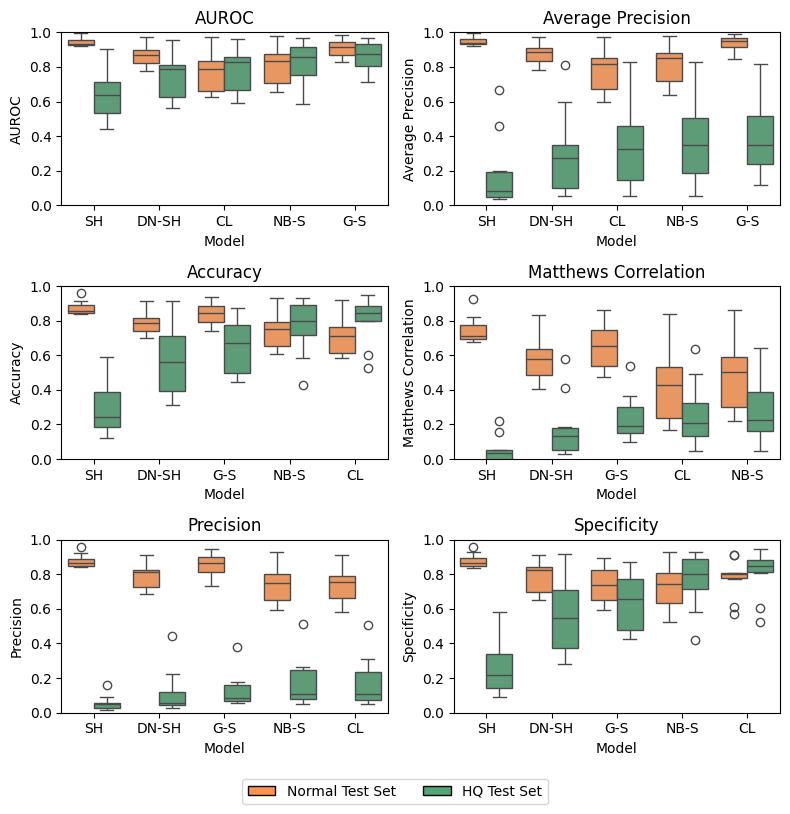

In [28]:
from matplotlib.patches import Patch

# Define the metrics to plot
metrics = [
    ('AUROC', 'AUROC_value', 'auroc_metric'),
    ('Average_Precision', 'Average_Precision_value', 'Average_Precision_metric'),
    ('Accuracy', 'Accuracy_value', 'Accuracy_metric'),
    ('Matthews_Correlation', 'Matthews_Correlation_value', 'Matthews_Correlation_metric'),
    ('Precision', 'Precision_value', 'Precision_metric'),
    ('Specificity', 'Specificity_value', 'Specificity_metric')
]

# Create figure with subplots
fig, axes = plt.subplots(3, 2, figsize=(8,8))
axes = axes.flatten()

palette_standard = {'HQ': color_list[5], 'Standard': color_list[1]}
palette_hq = {'HQ': color_list[6]}

for idx, (metric_name, value_col, metric_col) in enumerate(metrics):
    ax = axes[idx]
    
    # Prepare melted data for this metric
    melted_data = pd.melt(
        grouped_avg.sort_values(by=['TF-neg_mode']),
        id_vars=['neg_mode', "celltype", 'TF'],
        value_vars=[metric_name, f'{metric_name}_HQ'],
        var_name=metric_col,
        value_name=value_col
    )

    
    # Map the metric names
    melted_data[metric_col] = melted_data[metric_col].map({
        metric_name: 'Standard', 
        f'{metric_name}_HQ': 'HQ'
    })
    
    melted_data['neg_mode_short'] = melted_data['neg_mode'].map(neg_mode_labels)
    
    # Order by HQ performance
    hq_rows = melted_data[melted_data[metric_col] == 'HQ']
    mean_per_mode = hq_rows.groupby("neg_mode_short")[value_col].mean().sort_values(ascending=True)
    neg_mode_order_metric = mean_per_mode.index.tolist()
    
    melted_data["neg_mode_short"] = pd.Categorical(
        melted_data["neg_mode_short"], 
        categories=neg_mode_order_metric, 
        ordered=True
    )
    
    # Filter out HQ training for standard boxplots
    plot_data = melted_data#[melted_data['neg_mode'] != 'HQ training']
    
    # Create boxplot
    sns.boxplot(
        data=plot_data,
        x='neg_mode_short',
        y=value_col,
        hue=metric_col,
        palette=palette_standard,
        dodge=True,
        ax=ax
    )
    
    # Set labels and title
    ax.set_xlabel("Model")
    ax.set_ylabel(metric_name.replace('_', ' '))
    ax.set_title(f"{metric_name.replace('_', ' ')}")
    
    # Add reference line for AUROC
    # if metric_name == 'AUROC':
    #     ax.axhline(0.5, linestyle='--', color='red', linewidth=1)
    
    ax.set_ylim(0, 1)
    
    # Remove individual legends
    if ax.get_legend():
        ax.get_legend().remove()

# Add shared legend
legend_handles = [
    Patch(facecolor=palette_standard['Standard'], edgecolor='black', label='Normal Test Set'),
    Patch(facecolor=palette_standard['HQ'], edgecolor='black', label='HQ Test Set')
]
fig.legend(
    handles=legend_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.05),
    ncol=2,
    frameon=True
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("/data/home/natant/Negatives/figures/review_all_metrics_comparison.svg", 
             format='svg', dpi=300, bbox_inches='tight')
plt.show()

In [29]:
melted_group_avg = pd.melt(
    grouped_avg.sort_values(by=['TF-neg_mode']),
    id_vars=['neg_mode', "celltype", 'TF'],
    value_vars=['AUROC', 'AUROC_HQ'],
    var_name='auroc_metric',
    value_name='AUROC_value'
)

# Map the metric names to more descriptive labels
melted_group_avg['auroc_metric'] = melted_group_avg['auroc_metric'].map({'AUROC': 'Standard', 'AUROC_HQ': 'HQ'})

In [30]:
results_df["neg_mode_short"] = results_df["neg_mode"].map(neg_mode_labels)

In [31]:
# Calculate mean and median AUROC for each neg_mode-celltype combination
auroc_stats = results_df[results_df['neg_mode'] != 'HQ training'].groupby(['neg_mode_short', 'celltype'])['AUROC'].agg(['mean', 'median']).round(3)

# Reset index to make it easier to read
auroc_stats = auroc_stats.reset_index()
auroc_stats.columns = ['neg_mode', 'celltype', 'mean_AUROC', 'median_AUROC']

print("Mean and Median AUROC by neg_mode and celltype:")
print(auroc_stats)

# Pivot table for better visualization
pivot_mean = auroc_stats.pivot(index='celltype', columns='neg_mode', values='mean_AUROC')
pivot_median = auroc_stats.pivot(index='celltype', columns='neg_mode', values='median_AUROC')

print("\nMean AUROC by celltype and neg_mode:")
print(pivot_mean)

print("\nMedian AUROC by celltype and neg_mode:")
print(pivot_median)

Mean and Median AUROC by neg_mode and celltype:
  neg_mode celltype  mean_AUROC  median_AUROC
0       CL  GM12878       0.790         0.789
1    DN-SH  GM12878       0.870         0.868
2      G-S  GM12878       0.913         0.919
3     NB-S  GM12878       0.817         0.843
4       SH  GM12878       0.942         0.935

Mean AUROC by celltype and neg_mode:
neg_mode    CL  DN-SH    G-S   NB-S     SH
celltype                                  
GM12878   0.79   0.87  0.913  0.817  0.942

Median AUROC by celltype and neg_mode:
neg_mode     CL  DN-SH    G-S   NB-S     SH
celltype                                   
GM12878   0.789  0.868  0.919  0.843  0.935


In [32]:
# Calculate average AUROC per neg_mode across all TFs and celltypes
neg_mode_averages = results_df[results_df['neg_mode'] != 'HQ training'].groupby('neg_mode_short')['AUROC'].mean().sort_values(ascending=False)

print("Average AUROC by neg_mode (across all TFs and celltypes):")
for neg_mode, avg_auroc in neg_mode_averages.items():
    print(f"{neg_mode}: {avg_auroc:.3f}")

# Also calculate for AUROC_HQ
neg_mode_averages_hq = results_df[results_df['neg_mode'] != 'HQ training'].groupby('neg_mode_short')['AUROC_HQ'].mean().sort_values(ascending=False)

print("\nAverage AUROC_HQ by neg_mode (across all TFs and celltypes):")
for neg_mode, avg_auroc in neg_mode_averages_hq.items():
    print(f"{neg_mode}: {avg_auroc:.3f}")

Average AUROC by neg_mode (across all TFs and celltypes):
SH: 0.942
G-S: 0.913
DN-SH: 0.870
NB-S: 0.817
CL: 0.790

Average AUROC_HQ by neg_mode (across all TFs and celltypes):
G-S: 0.874
NB-S: 0.830
CL: 0.801
DN-SH: 0.757
SH: 0.647


In [33]:
# Calculate mean and median AUROC_HQ for each neg_mode-celltype combination
auroc_hq_stats = results_df[results_df['neg_mode'] != 'HQ training'].groupby(['neg_mode_short', 'celltype'])['AUROC_HQ'].agg(['mean', 'median']).round(3)

# Reset index to make it easier to read
auroc_hq_stats = auroc_hq_stats.reset_index()
auroc_hq_stats.columns = ['neg_mode', 'celltype', 'mean_AUROC_HQ', 'median_AUROC_HQ']

print("Mean and Median AUROC_HQ by neg_mode and celltype:")
print(auroc_hq_stats)

# Pivot table for better visualization
pivot_mean_hq = auroc_hq_stats.pivot(index='celltype', columns='neg_mode', values='mean_AUROC_HQ')
pivot_median_hq = auroc_hq_stats.pivot(index='celltype', columns='neg_mode', values='median_AUROC_HQ')

print("\nMean AUROC_HQ by celltype and neg_mode:")
print(pivot_mean_hq)

print("\nMedian AUROC_HQ by celltype and neg_mode:")
print(pivot_median_hq)

Mean and Median AUROC_HQ by neg_mode and celltype:
  neg_mode celltype  mean_AUROC_HQ  median_AUROC_HQ
0       CL  GM12878          0.801            0.829
1    DN-SH  GM12878          0.757            0.791
2      G-S  GM12878          0.874            0.886
3     NB-S  GM12878          0.830            0.856
4       SH  GM12878          0.647            0.647

Mean AUROC_HQ by celltype and neg_mode:
neg_mode     CL  DN-SH    G-S  NB-S     SH
celltype                                  
GM12878   0.801  0.757  0.874  0.83  0.647

Median AUROC_HQ by celltype and neg_mode:
neg_mode     CL  DN-SH    G-S   NB-S     SH
celltype                                   
GM12878   0.829  0.791  0.886  0.856  0.647


In [34]:
# Calculate average AUROC_HQ per neg_mode across all TFs and celltypes (including HQ training)
neg_mode_averages_hq_all = results_df.groupby('neg_mode_short')['AUROC_HQ'].mean().sort_values(ascending=False)

print("Average AUROC_HQ by neg_mode (across all individual TF runs, including HQ training):")
for neg_mode, avg_auroc in neg_mode_averages_hq_all.items():
    print(f"{neg_mode}: {avg_auroc:.3f}")

Average AUROC_HQ by neg_mode (across all individual TF runs, including HQ training):
G-S: 0.874
NB-S: 0.830
CL: 0.801
DN-SH: 0.757
SH: 0.647


In [35]:
melted_group_avg

,neg_mode,celltype,TF,auroc_metric,AUROC_value
0,celltype,GM12878,CTCF,Standard,0.972421
1,dinucl_sampled,GM12878,CTCF,Standard,0.981404
2,dinucl_shuffled,GM12878,CTCF,Standard,0.971354
3,neighbors,GM12878,CTCF,Standard,0.978891
4,shuffled,GM12878,CTCF,Standard,0.993318
...,...,...,...,...,...
97,celltype,GM12878,YY1_(SC-281),HQ,0.818297
98,dinucl_sampled,GM12878,YY1_(SC-281),HQ,0.866702
99,dinucl_shuffled,GM12878,YY1_(SC-281),HQ,0.769347
100,neighbors,GM12878,YY1_(SC-281),HQ,0.849414


## Figure: Motif performance

In [36]:
nice_names = {
    "dinucl_sampled": "Genome Sampled",
    "dinucl_shuffled": "Dinucl Shuffled",
    "neighbors": "Neighborhood Sampled",
    "shuffled": "Shuffled",
    "motif": "PWM",
    "celltype": "Cell Line Sampled",
    "HQ training": "HQ"
}

In [37]:
fused_df

,TF,AUROC_HQ,neg_mode,celltype
0,CTCF,0.962399,celltype,GM12878
1,CTCF,0.963947,dinucl_sampled,GM12878
2,CTCF,0.954123,dinucl_shuffled,GM12878
3,CTCF,0.966376,neighbors,GM12878
4,CTCF,0.902446,shuffled,GM12878
...,...,...,...,...
133,TCF12,0.453934,motif,HepG2
134,TCF7L2,0.836529,motif,HepG2
135,BHLHE40,0.884376,motif,HepG2
136,IRF3,0.519302,motif,HepG2


/tmp/ipykernel_2737389/517435764.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fused_df["neg_mode_short"] = fused_df["neg_mode"].map(neg_mode_labels)
/tmp/ipykernel_2737389/517435764.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fused_df["neg_mode_short"] = pd.Categorical(fused_df["neg_mode_short"], categories=neg_mode_order, ordered=True)
/tmp/ipykernel_2737389/517435764.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer

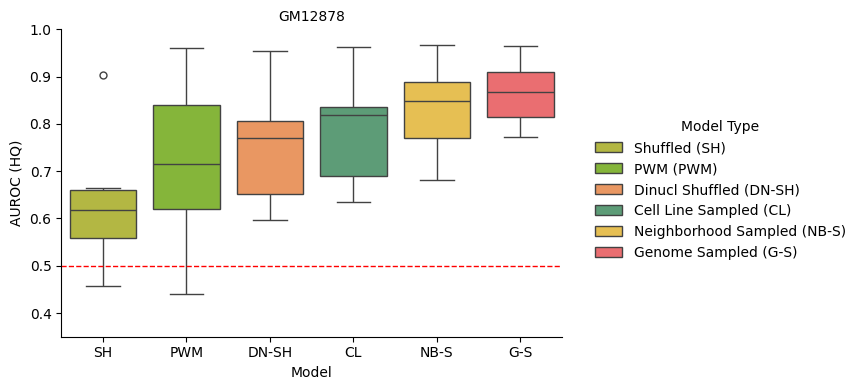

In [38]:
# Compute mean AUROC_HQ per neg_mode_short for ordering
fused_df = fused_df[fused_df["celltype"] == "GM12878"]
fused_df["neg_mode_short"] = fused_df["neg_mode"].map(neg_mode_labels)
mean_per_mode = fused_df.groupby("neg_mode_short")["AUROC_HQ"].mean().sort_values()
neg_mode_order = mean_per_mode.index.tolist()

# Set categorical order for plotting
fused_df["neg_mode_short"] = pd.Categorical(fused_df["neg_mode_short"], categories=neg_mode_order, ordered=True)

# Create nice names with abbreviations in brackets
nice_names_with_abbrev = {
    "dinucl_sampled": "Genome Sampled (G-S)",
    "dinucl_shuffled": "Dinucl Shuffled (DN-SH)",
    "neighbors": "Neighborhood Sampled (NB-S)",
    "shuffled": "Shuffled (SH)",
    "motif": "PWM (PWM)",
    "celltype": "Cell Line Sampled (CL)",
    "HQ training": "HQ (HQ)"
}

# Add a column with nice names for neg_mode, also with the same categorical order
fused_df["neg_mode_nice"] = fused_df["neg_mode"].map(nice_names_with_abbrev)

# Create inverse mapping for neg_mode_labels
neg_mode_labels_inv = {v: k for k, v in neg_mode_labels.items()}

nice_name_order = [nice_names_with_abbrev[neg_mode_labels_inv[short]] for short in neg_mode_order]
fused_df["neg_mode_nice"] = pd.Categorical(fused_df["neg_mode_nice"], categories=nice_name_order, ordered=True)

g = sns.catplot(
    data=fused_df,
    x='neg_mode_short',
    col='celltype',
    y='AUROC_HQ',
    hue='neg_mode_nice',
    kind='box',
    height=4,
    aspect=0.8,
    palette={nice_names_with_abbrev[k]: color_list[i] for i, k in enumerate(neg_mode_labels.keys())}
)
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Model", "AUROC (HQ)")
g._legend.set_bbox_to_anchor((1, 0.5))
g._legend.set_loc("center left")
g._legend.set_title("Model Type")
g.set(ylim=(0.35, 1))
for ax in g.axes.flatten():
    ax.axhline(0.5, linestyle='--', color='red', linewidth=1)
plt.tight_layout()
#plt.savefig("/data/home/natant/Negatives/figures/Baselines.svg", format='svg', dpi=300, bbox_inches='tight')
plt.show()


/tmp/ipykernel_2737389/2264509360.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fused_df["neg_mode_short"] = fused_df["neg_mode"].map(neg_mode_labels)
/tmp/ipykernel_2737389/2264509360.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fused_df["neg_mode_short"] = pd.Categorical(fused_df["neg_mode_short"], categories=neg_mode_order, ordered=True)
/tmp/ipykernel_2737389/2264509360.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_inde

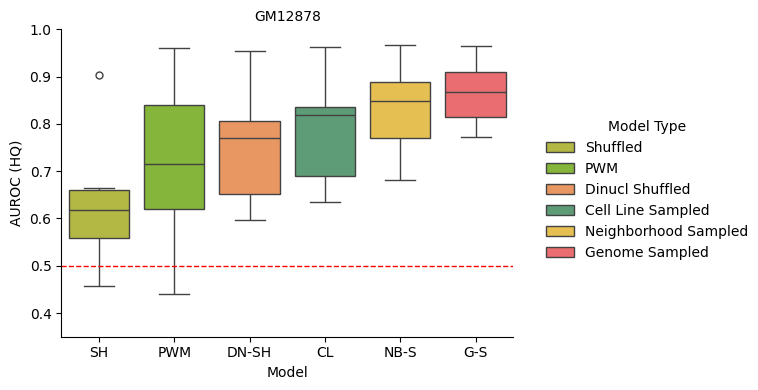

In [39]:
# Compute mean AUROC_HQ per neg_mode_short for ordering
fused_df["neg_mode_short"] = fused_df["neg_mode"].map(neg_mode_labels)
mean_per_mode = fused_df.groupby("neg_mode_short")["AUROC_HQ"].mean().sort_values()
neg_mode_order = mean_per_mode.index.tolist()

# Set categorical order for plotting
fused_df["neg_mode_short"] = pd.Categorical(fused_df["neg_mode_short"], categories=neg_mode_order, ordered=True)

# Add a column with nice names for neg_mode, also with the same categorical order
fused_df["neg_mode_nice"] = fused_df["neg_mode"].map(nice_names)

# Create inverse mapping for neg_mode_labels
neg_mode_labels_inv = {v: k for k, v in neg_mode_labels.items()}

nice_name_order = [nice_names[neg_mode_labels_inv[short]] for short in neg_mode_order]
fused_df["neg_mode_nice"] = pd.Categorical(fused_df["neg_mode_nice"], categories=nice_name_order, ordered=True)



g = sns.catplot(
    data=fused_df,
    x='neg_mode_short',
    col='celltype',
    y='AUROC_HQ',
    hue='neg_mode_nice',
    kind='box',
    height=4,
    aspect=0.8,
    palette={nice_names[k]: color_list[i] for i, k in enumerate(neg_mode_labels.keys())}
)
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Model", "AUROC (HQ)")
g._legend.set_bbox_to_anchor((1, 0.5))
g._legend.set_loc("center left")
g._legend.set_title("Model Type")
g.set(ylim=(0.35, 1))
for ax in g.axes.flatten():
    ax.axhline(0.5, linestyle='--', color='red', linewidth=1)
plt.tight_layout()
#plt.savefig("/data/home/natant/Negatives/figures/Baselines.svg", format='svg', dpi=300, bbox_inches='tight')
plt.show()


In [40]:
alternative_colors = {'celltype': '#1f77b4',
 'dinucl_sampled': '#ff7f0e',
 'dinucl_shuffled': '#2ca02c',
 'HQ': '#d62728',
 'neighbors': '#9467bd',
 'shuffled': '#8c564b'}

In [41]:
neg_mode_labels

{'dinucl_sampled': 'G-S',
 'dinucl_shuffled': 'DN-SH',
 'neighbors': 'NB-S',
 'shuffled': 'SH',
 'motif': 'PWM',
 'celltype': 'CL',
 'HQ training': 'HQ'}

In [42]:
{nice_names_with_abbrev[k]: color_list[i] for i, k in enumerate(neg_mode_labels.keys())}

{'Genome Sampled (G-S)': '#ff595e',
 'Dinucl Shuffled (DN-SH)': '#ff924c',
 'Neighborhood Sampled (NB-S)': '#ffca3a',
 'Shuffled (SH)': '#c5ca30',
 'PWM (PWM)': '#8ac926',
 'Cell Line Sampled (CL)': '#52a675',
 'HQ (HQ)': '#1982c4'}

## Figure: Motif vs Dincul shuffled

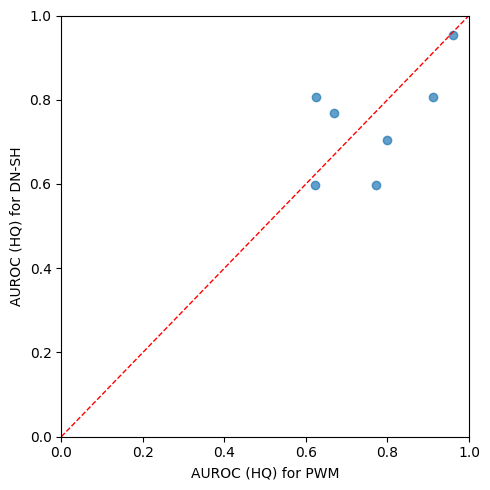

In [43]:
import matplotlib.pyplot as plt

# Filter fused_df for only 'motif' and 'dinucl_shuffled' neg_mode
compare_modes = ['motif', 'dinucl_shuffled']
df1 = fused_df[fused_df['neg_mode'] == 'motif'][['TF', 'celltype', 'AUROC_HQ']]
df2 = fused_df[fused_df['neg_mode'] == 'dinucl_shuffled'][['TF', 'celltype', 'AUROC_HQ']]

# Merge on TF and celltype to align the two modes
merged = pd.merge(
    df1, df2,
    on=['TF', 'celltype'],
    suffixes=('_motif', '_dinucl_shuffled')
)

plt.figure(figsize=(5, 5))
plt.scatter(
    merged['AUROC_HQ_motif'],
    merged['AUROC_HQ_dinucl_shuffled'],
    alpha=0.7
)
plt.plot([0, 1], [0, 1], 'r--', linewidth=1, label='y=x')
plt.xlabel('AUROC (HQ) for PWM')
plt.ylabel('AUROC (HQ) for DN-SH')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout()
# plt.savefig("/data/home/natant/Negatives/figures/performance_comparison_DN-SH_vs_PWM.svg", 
#             format='svg', dpi=300, bbox_inches='tight')
plt.show()

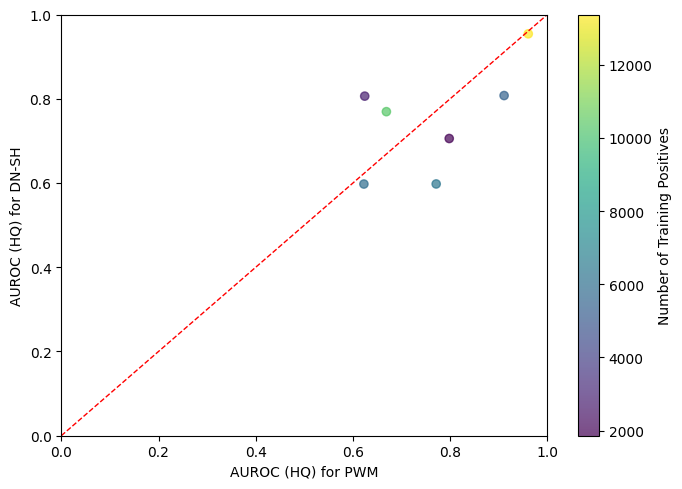

In [44]:
import matplotlib.pyplot as plt

# Filter fused_df for only 'motif' and 'dinucl_shuffled' neg_mode
compare_modes = ['motif', 'dinucl_shuffled']
df1 = fused_df[fused_df['neg_mode'] == 'motif'][['TF', 'celltype', 'AUROC_HQ']]
df2 = fused_df[fused_df['neg_mode'] == 'dinucl_shuffled'][['TF', 'celltype', 'AUROC_HQ']]

# Merge on TF and celltype to align the two modes
merged = pd.merge(
    df1, df2,
    on=['TF', 'celltype'],
    suffixes=('_motif', '_dinucl_shuffled')
)

# Get number of positives for each TF-celltype combination
# Use grouped_avg to get num_training_positives
num_positives = grouped_avg[grouped_avg['neg_mode'] == 'dinucl_shuffled'][['TF', 'celltype', 'num_training_positives']].drop_duplicates()
merged = pd.merge(merged, num_positives, on=['TF', 'celltype'], how='left')
merged[(merged["num_training_positives"] <= 16000) & (merged["num_training_positives"] >= 500)]

plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    merged['AUROC_HQ_motif'],
    merged['AUROC_HQ_dinucl_shuffled'],
    c=merged['num_training_positives'],
    cmap='viridis',
    alpha=0.7
)
plt.colorbar(scatter, label='Number of Training Positives')
plt.plot([0, 1], [0, 1], 'r--', linewidth=1, label='y=x')
plt.xlabel('AUROC (HQ) for PWM')
plt.ylabel('AUROC (HQ) for DN-SH')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout()
# plt.savefig("/data/home/natant/Negatives/figures/performance_comparison_DN-SH_vs_PWM.svg", 
#             format='svg', dpi=300, bbox_inches='tight')
plt.show()